<div align="center">

# Genetic Melody Reconstruction
## Evolving Frequency Sequences to Match a Target Melody

**Sarina Mahmoudi**

</div>

---


In [7]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import soundfile as sf
import scipy.io.wavfile as wavfile


## Part 1: Melody Extraction

Before the genetic algorithm can start evolving, it needs a target sequence to compare against.

The code below takes an audio file (`.wav`), cuts it into small chunks based on `note_duration`, and uses the Fast Fourier Transform (FFT) to find the dominant frequency (pitch) in each chunk.
- A frequency of `0` means silence.
- Other numbers (e.g., `440`, `262`) represent musical notes.


### Extracting Frequencies from Audio


In [8]:
def extract_frequencies_from_wav(filename, note_duration, sample_rate=44100):
    sr, data = wavfile.read(filename)
    chunk_samples = int(sr * note_duration)
    extracted_freqs = []
    num_chunks = len(data) // chunk_samples
    max_amplitude = np.max(np.abs(data))
    silence_threshold = max_amplitude * 0.05   

    for i in range(num_chunks):
        start = i * chunk_samples
        end = start + chunk_samples
        chunk = data[start:end]
        
        if np.max(np.abs(chunk)) < silence_threshold:
            extracted_freqs.append(0)
            continue
            
        mid_start = int(0.20 * len(chunk))
        mid_end = int(0.80 * len(chunk))
        focus_chunk = chunk[mid_start:mid_end]
        
        window = np.hanning(len(focus_chunk))
        windowed_chunk = focus_chunk * window
        
        N_padded = sample_rate * 2 
        
        fft_result = np.fft.fft(windowed_chunk, n=N_padded)
        freqs = np.fft.fftfreq(N_padded, 1/sr)
        
        pos_mask = (freqs > 20) & (freqs < 2000)
        fft_result = np.abs(fft_result[pos_mask])
        freqs = freqs[pos_mask]
        
        if len(fft_result) == 0:
            extracted_freqs.append(0)
            continue
            
        peak_idx = np.argmax(fft_result)
        peak_freq = freqs[peak_idx]
        
        extracted_freqs.append(int(round(peak_freq)))

    while extracted_freqs and extracted_freqs[-1] == 0:
        extracted_freqs.pop()

    return extracted_freqs

if __name__ == "__main__":

    path1 = "../data/target_melodies/got_target.wav"
    path2 = "../data/target_melodies/interstellar_target.wav"
    path3 = "../data/target_melodies/harry_potter_target.wav"
    path4 = "../data/target_melodies/bella_ciao_target.wav"
    path5 = "../data/target_melodies/mario_target.wav"
    path6 = "../data/target_melodies/pink_panther_target.wav"
    path7 = "../data/target_melodies/fur_elise_target.wav"
    path8 = "../data/target_melodies/swan_lake_target.wav"
    path9 = "../data/target_melodies/squid_game_target.wav"

    songs = {
        path1: 0.25,
        path2: 0.25,
        path3: 0.25,
        path4: 0.25,
        path5: 0.20,
        path6: 0.25,
        path7: 0.30,
        path8: 0.30,
        path9: 0.30
    }
    test_file = path7
    duration = songs[test_file]
    target_frequencies = extract_frequencies_from_wav(test_file, note_duration=duration)
    print(f"Target Array Length: {len(target_frequencies)}")


Target Array Length: 40


# <span style="color: #3498db;">Genetic Algorithm</span>

---
## Part 2: The Genetic Algorithm Class

`GeneticAlgorithm` owns the population and drives the evolutionary loop: initialization, fitness scoring, selection, crossover, and mutation.

All of the heavy lifting is done with vectorized NumPy operations rather than per-individual Python loops, which matters a lot once population size and chromosome length grow.


In [ ]:
threshold = 10

class GeneticAlgorithm:
    def __init__(self, target_frequencies, pop_size, generations, mutation_rate, min_freq=0, max_freq=2000):
        """Initializes the Genetic Algorithm."""
        self.target_frequencies = target_frequencies
        self.pop_size = pop_size
        self.generations = generations
        self.mutation_rate = mutation_rate
        self.chromosome_length = len(target_frequencies)
        self.min_freq = min_freq
        self.max_freq = max_freq
        
        # We will store the history of the best fitness score in each generation
        self.best_fitness_history = []
        self.best_chromosome = None
        
        # Initialize the first population
        self.population = self._initialize_population()

    def _initialize_population(self):
        """
        Creates the initial random population.
        Returns:
            np.array: Population array of shape (pop_size, chromosome_length).
        """
        # np.random.randint uses a half-open interval, hence max_freq + 1
        a = np.random.randint(low=self.min_freq, high=self.max_freq+1, size=(self.pop_size, self.chromosome_length))
        return a
    
    def _calculate_fitness_mae(self):
        """
        Calculates the fitness score for each individual in the population.
        Fitness should be inversely proportional to the error (e.g., MAE).
        Returns:
            np.array: Fitness scores for the current population.
        """
        errors = np.mean(np.abs(self.population - self.target_frequencies), axis=1)
        fitness = 1 / (1 + errors)
        return fitness
    
    def _calculate_fitness_mse(self):
        
        errors = np.mean(np.square(self.population - self.target_frequencies), axis=1)
        fitness = 1 / (1 + errors)
        return fitness
    
    def _calculate_fitness_hamming(self):
        fitness_scores = []
        for individual in self.population:
            diffs = np.abs(individual - self.target_frequencies)
            no_mismatch = np.sum(diffs > threshold)
            
            fitness = 1 / (1 + no_mismatch) 
            fitness_scores.append(fitness)
        return np.array(fitness_scores)

    def _calculate_fitness_correlation(self):
        correlation = []
        if not len(self.target_frequencies) or not len(self.population):
            return np.zeros(len(self.population)) # Return array of zeros matching population size

        for individual in self.population:
            # np.corrcoef returns a 2x2 matrix:
            # We want the correlation between the individual and the target, which is at index [0, 1] or [1, 0].
            correlation_matrix = np.corrcoef(individual, self.target_frequencies)
            if correlation_matrix.shape == (2, 2):
                correlation_score = correlation_matrix[0, 1]
            else:
                correlation_score = 0.0 # Assign a default low fitness

            # Handle potential NaN values
            if np.isnan(correlation_score):
                correlation_score = 0.0 
            correlation.append(abs(correlation_score))
        return np.array(correlation)

    def _calculate_fitness_jaccard(self):
        
        fitness_scores = []     
        for individual in self.population:
            jaccard_score = self._multiset_jaccard(individual, self.target_frequencies)
            fitness_scores.append(jaccard_score)
        fitness_scores = np.array(fitness_scores)
        fitness_scores = fitness_scores+ self._calculate_fitness_mae()

        return fitness_scores
    
    def _multiset_jaccard(self, individual, target):
        """
        Calculates the generalized Jaccard index between two multisets.
        
        Args:
            individual (np.array): The candidate chromosome (individual).
            target (np.array): The target chromosome (frequencies).

        Returns:
            float: Jaccard index value.
        """
        individual_counts = np.bincount(individual, minlength=self.max_freq + 1)
        target_counts = np.bincount(target)

        intersection = np.minimum(individual_counts, target_counts).sum()
        union = np.maximum(individual_counts, target_counts).sum()

        if union == 0:  # To avoid division by zero
            return 0.0
        else:
            return intersection / union

    def _selection_tournament(self, num_parents, fitness_values):
        """
        Selects parents for the next generation using tournament selection.

        Args:
            num_parents (int): Number of parents to select.
        Returns:
            np.array: Selected parents.
        """
        selected_parents = []
        k = max(int( num_parents / 20) , 3)
        
        for _ in range(num_parents):
            # Pick k random indices from the population
            tournament_indices = np.random.choice(len(self.population), size=k, replace=False)
            winner_index = tournament_indices[np.argmax(fitness_values[tournament_indices])]
            selected_parents.append(self.population[winner_index])


        return np.array(selected_parents)

    def _selection_roulette(self, num_parents, fitness_values):
        population_indices = np.arange(len(self.population))
        
        if np.all(fitness_values == 0):
        # If all fitness values are zero, assign equal probability to all
            probabilities = np.ones(len(self.population)) / len(self.population)
        else:
        # Normalize fitness values
            total_fitness = np.sum(fitness_values)
            probabilities = fitness_values / total_fitness
            
    
        selected_indices = np.random.choice(population_indices, size=num_parents, replace=True, p=probabilities)
        selected_parents = self.population[selected_indices]

        return selected_parents
    
    def _selection_ranked(self, num_parents, fitness_values):
        #anti_sort
        ranked_indices = np.argsort(fitness_values)
        n = self.pop_size
        ranks = np.arange(n)
        probabilities = 2 * (ranks + 1) / (n * (n + 1))

        selected_ranks = np.random.choice(ranks,size=num_parents,replace=True,p=probabilities)
        selected_indices = ranked_indices[selected_ranks]

        selected_parents = self.population[selected_indices]

        return selected_parents
    
    def _selection_elitism(self, num_parents, fitness_values):
        #anti_sort
        ranked_indices = np.argsort(fitness_values)[::-1]
        selected_indices = ranked_indices[:num_parents]

        selected_parents = self.population[selected_indices]

        return selected_parents
    
    def _crossover(self, parents, offspring_size):
        """
        Performs crossover between selected parents to create offspring.
        (e.g., Single-Point or Two-Point Crossover)
        
        Args:
            parents (np.array): Selected parent chromosomes.
            offspring_size (int): Number of offspring to generate.
        Returns:
            np.array: Generated offspring.
        """
        n = self.chromosome_length
        offspring = np.empty((offspring_size, n), dtype=parents.dtype)
        num_pairs = offspring_size // 2

        crossover_points = np.random.randint(1, n, size=num_pairs)
        # Avoid point 0 and n to ensure actual crossover

        parent_indices = np.arange(len(parents))
        np.random.shuffle(parent_indices) 
    
        for i in range(num_pairs):
        
            parent1 = parents[parent_indices[2*i]]
            parent2 = parents[parent_indices[2*i + 1]]
        
            cp = crossover_points[i]
            offspring[2*i] = np.concatenate((parent1[:cp], parent2[cp:]))    
            offspring[2*i+1] = np.concatenate((parent2[:cp], parent1[cp:]))

        # Handle the case where offspring_size is odd
        if offspring_size % 2 == 1:
            parent1 = parents[parent_indices[2*(num_pairs-1)] ]
            parent2 = parents[parent_indices[2*(num_pairs-1) + 1]]
            last_cp = np.random.randint(1, n)
            offspring[-1] = np.concatenate((parent1[:last_cp], parent2[last_cp:]))

        return offspring
    
    def _crossover_two_point(self, parents, offspring_size):
        n = self.chromosome_length
        offspring = np.empty((offspring_size, n), dtype=parents.dtype)

        for i in range(offspring_size):
            parent1, parent2 = parents[np.random.choice(len(parents), size=2, replace=True)]

            point1, point2 = np.sort(
                np.random.choice(np.arange(1, n), size=2, replace=False)
            )

            child = parent1.copy()
            child[point1:point2] = parent2[point1:point2]
            offspring[i] = child

        return offspring
    
    def _crossover_uniform(self, parents, offspring_size):
        n = self.chromosome_length
        offspring = np.empty((offspring_size, n), dtype=parents.dtype)

        for i in range(offspring_size):
            parent1, parent2 = parents[np.random.choice(len(parents), size=2, replace=True)]

            mask = np.random.rand(n) < 0.5
            child = np.where(mask, parent1, parent2)
            offspring[i] = child

        return offspring
    
    def _mutation(self, offspring):
        """
        Applies random mutations to the offspring based on mutation_rate.
        Args:
            offspring (np.array): The newly generated offspring chromosomes.
        Returns:
            np.array: Mutated offspring.
        """
        num_offspring = offspring.shape[0]
        chromosome_length = self.chromosome_length
        mutation_mask = np.random.rand(num_offspring, chromosome_length) < self.mutation_rate
        new_genes = np.random.randint(low=self.min_freq, high=self.max_freq+1, size=(num_offspring, chromosome_length))
        
        offspring[mutation_mask] = new_genes[mutation_mask]
        return offspring
    
    def run(self, fitness_method="hamming", selection_method="tournament",
            crossover_method="single_point", num_elites=2):
        """
        Runs the evolutionary loop for self.generations generations using the
        given fitness / selection / crossover strategies, and returns the
        best chromosome found.
        """
    
        fitness_methods = {
            "mae": self._calculate_fitness_mae,
            "mse": self._calculate_fitness_mse,
            "hamming": self._calculate_fitness_hamming,
            "correlation": self._calculate_fitness_correlation,
            "jaccard": self._calculate_fitness_jaccard,
        }

        selection_methods = {
            "tournament": self._selection_tournament,
            "roulette": self._selection_roulette,
            "ranked": self._selection_ranked,
            "elitism": self._selection_elitism,
        }
        crossover_methods = {
            "single_point": self._crossover,
            "two_point": self._crossover_two_point,
            "uniform": self._crossover_uniform,
        }
        if fitness_method not in fitness_methods:
            raise ValueError(f"Unknown fitness_method: {fitness_method}")
        if selection_method not in selection_methods:
            raise ValueError(f"Unknown selection_method: {selection_method}")
        if crossover_method not in crossover_methods:
            raise ValueError(f"Unknown crossover_method: {crossover_method}")

        fitness_func = fitness_methods[fitness_method]
        selection_func = selection_methods[selection_method]
        crossover_func = crossover_methods[crossover_method]

        for _ in range(self.generations):
            fitness = fitness_func()

            best_idx = np.argmax(fitness)
            best_fit = fitness[best_idx]

            if not self.best_fitness_history or best_fit > max(self.best_fitness_history):
                self.best_chromosome = self.population[best_idx].copy()

            self.best_fitness_history.append(best_fit)

            elites = self._selection_elitism(num_elites, fitness)

            num_offspring = self.pop_size - num_elites

            parents = selection_func(num_offspring, fitness)

            offspring = crossover_func(parents, num_offspring)

            offspring = self._mutation(offspring)

            self.population = np.vstack([elites, offspring])

        final_fitness = fitness_func()
        best_idx = np.argmax(final_fitness)

        if final_fitness[best_idx] > max(self.best_fitness_history):
            self.best_chromosome = self.population[best_idx].copy()
            self.best_fitness_history.append(final_fitness[best_idx])

        return self.best_chromosome
     

### Fitness function notes

Five fitness functions are implemented, each scoring a chromosome by a different notion of "closeness" to the target frequencies.

`_calculate_fitness_mae` averages the absolute difference between a chromosome's genes and the target, then inverts it into a fitness score. Because it's linear in the error, it's forgiving of small per-note deviations and gives the search a smooth gradient to climb.

`_calculate_fitness_mse` does the same thing but squares the differences first, so large mismatches get punished disproportionately. That tends to speed up early convergence when the population starts far from the target, at the cost of being more sensitive to noisy or outlier genes.

`_calculate_fitness_hamming` takes a different approach entirely: instead of measuring how far off each gene is, it just counts how many genes miss the target by more than a `threshold`. Everything within tolerance counts the same, and everything outside it counts the same too. That makes it a good fit when the real goal is "close enough" note matching rather than exact numeric equality — the search spends its pressure eliminating big misses instead of fine-tuning differences the ear probably won't notice.

`_calculate_fitness_correlation` ignores absolute values and instead checks the Pearson correlation between a chromosome and the target, so it rewards matching the overall shape of the melody's ups and downs even if the exact pitches are off.

`_calculate_fitness_jaccard` treats both sequences as multisets and compares them by the ratio of shared note counts to combined note counts, so it rewards having the right notes without caring where in the sequence they land.

In practice, MAE-based fitness gave the best balance for this problem — continuous, forgiving of small errors, and fast to converge without the volatility MSE introduces from outliers.


### Selection method notes

Four selection strategies are implemented for choosing which individuals get to reproduce each generation.

`_selection_roulette` treats each individual's fitness as a slice of a wheel, so higher-fitness individuals get proportionally more chances of being picked. It works well when fitness values are spread out, but it's prone to premature convergence: once one or two individuals dominate the fitness scale, they get selected over and over and diversity collapses fast.

`_selection_ranked` sidesteps that by ignoring raw fitness magnitudes. Individuals are sorted and given a selection probability based on rank instead of value, which keeps things stable even when fitness scores are noisy or wildly uneven — at the cost of converging more slowly once the population is already close to the target.

`_selection_elitism` just carries the best individuals straight into the next generation, guaranteeing the current-best solution is never lost to random sampling. Pushed too far, though, it over-concentrates the population around whatever's currently best and can stall out in a local optimum.

`_selection_tournament` samples a small random group each time and picks the fittest member of that group as a parent. Because the contest is local rather than global, tournament size becomes a dial: a bigger tournament pushes harder toward the fittest individuals, a smaller one preserves more diversity.

Tournament selection (paired with a couple of kept elites) ended up the best general default here — less prone to the scaling problems that trip up roulette wheel, and less likely to over-freeze the population than pure elitism, while still consistently pushing toward better matches.


**One-point crossover** picks a single crossover index cp and creates two offspring by taking a contiguous prefix from one parent and the remaining suffix from the other (swapping which parent supplies the prefix for the second child). **Two-point crossover** chooses two indices point1 < point2, copies parent1, and then replaces the contiguous middle segment with the corresponding segment from parent2. **Uniform crossover** mixes at the gene level: for each position, it randomly chooses whether the child inherits that gene from parent1 or parent2, so there’s no contiguous block preserved.
I used **one-point crossover** because each chromosome has an order where neighboring (contiguous) positions are meaningful. One-point tends to preserve useful building blocks (prefix/suffix patterns) more than uniform crossover, which can disrupt structure by mixing every gene independently, and it’s often less disruptive than two-point because it uses only one boundary rather than two. Overall, since the goal here is position-aligned matching, one-point is a strong, practical default that maintains locality in the genome while still combining parental information effectively.

---
## Part 3: Visualization

Plotting the best chromosome against the target frequencies makes it easy to see which notes the algorithm learned and which ones it missed.


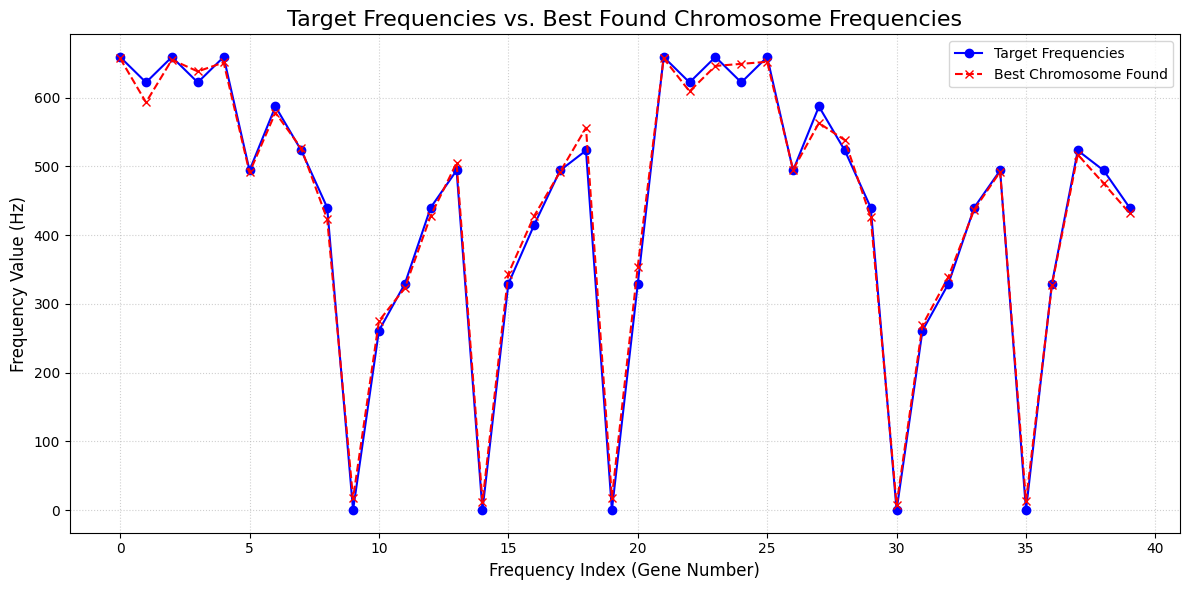

In [10]:
target_frequencies = extract_frequencies_from_wav(test_file, note_duration=duration)
for_elise = GeneticAlgorithm(target_frequencies, 1000, 100, 0.02, min(target_frequencies), max(target_frequencies))
best_chromosome=for_elise.run()
plt.figure(figsize=(12, 6))
frequency_indices = np.arange(len(target_frequencies))
plt.plot(frequency_indices, target_frequencies, marker='o', linestyle='-', color='blue', label='Target Frequencies')
if for_elise.best_chromosome is not None:
    plt.plot(frequency_indices, for_elise.best_chromosome, marker='x', linestyle='--', color='red', label='Best Chromosome Found')
else:
    print("Warning: Best chromosome was not found or is None. Cannot plot it.")
plt.title('Target Frequencies vs. Best Found Chromosome Frequencies', fontsize=16)
plt.xlabel('Frequency Index (Gene Number)', fontsize=12)
plt.ylabel('Frequency Value (Hz)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

In [19]:
import numpy as np
import matplotlib.pyplot as plt


def compare_ga_methods_to_files(
    target_frequencies,
    pop_size=100,
    generations=100,
    mutation_rate=0.05,
    min_freq=0,
    max_freq=2000,
    fitness_methods=None,
    selection_methods=None,
    crossover_methods=None,
    fixed_fitness="mae",
    fixed_selection="ranked",
    fixed_crossover="single_point",
    num_elites=2,
    runs_per_method=3,
    output_prefix=""
):
    if fitness_methods is None:
        fitness_methods = ["mae", "mse", "hamming", "correlation", "jaccard"]
    if selection_methods is None:
        selection_methods = ["tournament", "roulette", "ranked"]
    if crossover_methods is None:
        crossover_methods = ["single_point", "two_point", "uniform"]
    results = {
        "fitness": {},
        "selection": {},
        "crossover": {}
    }

    def run_one_config(fitness_method, selection_method, crossover_method):

        all_histories = []
        final_maes = []
        best_chromosomes = []

        for _ in range(runs_per_method):
            ga = GeneticAlgorithm(target_frequencies=target_frequencies,pop_size=pop_size,generations=generations,mutation_rate=mutation_rate,min_freq=min_freq,max_freq=max_freq)
            best = ga.run(fitness_method=fitness_method,selection_method=selection_method,crossover_method=crossover_method,num_elites=num_elites)
            history = ga.best_fitness_history[:generations]
            if len(history) == 0:
                history = [0.0] * generations
            elif len(history) < generations:
                history = history + [history[-1]] * (generations - len(history))
            all_histories.append(history)
            mae = np.mean(np.abs(best - target_frequencies))
            final_maes.append(mae)
            best_chromosomes.append(best)
        all_histories = np.array(all_histories)
        mean_history = np.mean(all_histories, axis=0)
        std_history = np.std(all_histories, axis=0)
        best_run_idx = np.argmax(final_maes)
        return {
            "mean_history": mean_history,
            "std_history": std_history,
            "mean_final_mae": float(np.mean(final_maes)),
            "std_final_mae": float(np.std(final_maes)),
            "best_mae": float(final_maes[best_run_idx]),
            "best_chromosome": best_chromosomes[best_run_idx]
        }
    plt.figure(figsize=(12, 7))
    for fitness_method in fitness_methods:
        stats = run_one_config(fitness_method=fitness_method,selection_method=fixed_selection,crossover_method=fixed_crossover)
        results["fitness"][fitness_method] = stats
        mean_history = stats["mean_history"]
        std_history = stats["std_history"]
        plt.plot(mean_history, label=fitness_method)
        if runs_per_method > 1:
            plt.fill_between(
                range(len(mean_history)),
                mean_history - std_history,
                mean_history + std_history,
                alpha=0.15
            )
    plt.title(
        f"Fitness Comparison\n"
        f"(selection={fixed_selection}, crossover={fixed_crossover})"
    )
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    fitness_file = f"{output_prefix}fitness_comparison.png"
    plt.savefig(fitness_file, dpi=300, bbox_inches="tight")
    plt.close()
    plt.figure(figsize=(12, 7))
    for selection_method in selection_methods:
        stats = run_one_config(fitness_method=fixed_fitness,selection_method=selection_method,crossover_method=fixed_crossover)
        results["selection"][selection_method] = stats
        mean_history = stats["mean_history"]
        std_history = stats["std_history"]
        plt.plot(mean_history, label=selection_method)
        if runs_per_method > 1:
            plt.fill_between(
                range(len(mean_history)),
                mean_history - std_history,
                mean_history + std_history,
                alpha=0.15
            )
    plt.title(
        f"Selection Comparison\n"
        f"(fitness={fixed_fitness}, crossover={fixed_crossover})"
    )
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    selection_file = f"{output_prefix}selection_comparison.png"
    plt.savefig(selection_file, dpi=300, bbox_inches="tight")
    plt.close()
    plt.figure(figsize=(12, 7))
    for crossover_method in crossover_methods:
        stats = run_one_config(fitness_method=fixed_fitness, selection_method=fixed_selection, crossover_method=crossover_method)
        results["crossover"][crossover_method] = stats
        mean_history = stats["mean_history"]
        std_history = stats["std_history"]
        plt.plot(mean_history, label=crossover_method)
        if runs_per_method > 1:
            plt.fill_between(range(len(mean_history)),mean_history - std_history,mean_history + std_history,alpha=0.15)
    plt.title(
        f"Crossover Comparison\n"
        f"(fitness={fixed_fitness}, selection={fixed_selection})")
    plt.xlabel("Generation")
    plt.ylabel("Best Fitness")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    crossover_file = f"{output_prefix}crossover_comparison.png"
    plt.savefig(crossover_file, dpi=300, bbox_inches="tight")
    plt.close()
    print("Saved files:")
    print(f" - {fitness_file}")
    print(f" - {selection_file}")
    print(f" - {crossover_file}")

    return results

target = np.array([440, 550, 660, 770, 880])
results = compare_ga_methods_to_files(target_frequencies=target, pop_size=100, generations=150, mutation_rate=0.05, fitness_methods=["mae", "mse", "hamming"],
    selection_methods=["tournament", "ranked", "roulette"], crossover_methods=["single_point", "two_point", "uniform"],
    fixed_fitness="mae", fixed_selection="ranked", fixed_crossover="single_point", runs_per_method=3, output_prefix="")

for category in results:
    print(f"\n{category.upper()} RESULTS")
    sorted_items = sorted(results[category].items(), key=lambda x: x[1]["mean_final_mae"])
    for name, data in sorted_items:
        print(f"{name}: mean_final_mae={data['mean_final_mae']:.4f}, "f"best_mae={data['best_mae']:.4f}")

Saved files:
 - fitness_comparison.png
 - selection_comparison.png
 - crossover_comparison.png

FITNESS RESULTS
mse: mean_final_mae=1.8000, best_mae=3.0000
mae: mean_final_mae=3.3333, best_mae=4.6000
hamming: mean_final_mae=4.8000, best_mae=5.6000

SELECTION RESULTS
tournament: mean_final_mae=1.7333, best_mae=2.4000
ranked: mean_final_mae=2.1333, best_mae=2.4000
roulette: mean_final_mae=2.4667, best_mae=4.2000

CROSSOVER RESULTS
single_point: mean_final_mae=1.4000, best_mae=1.8000
two_point: mean_final_mae=2.6000, best_mae=3.6000
uniform: mean_final_mae=2.6667, best_mae=3.4000


---
## Part 4: Listening to the Result

The function below turns a frequency array into an actual audio file using sine waves, harmonics, vibrato, and echo. Use the same `note_duration` that was used when extracting the target frequencies.


In [ ]:
from scipy.io import wavfile

def frequencies_to_melody(frequencies, output_filename="ai_melody_clean.wav", note_duration=0.25, sample_rate=44100):
    """Generates a clean, standard synth sound (Good for checking accuracy)."""
    print(f"Synthesizing Clean Audio: {output_filename}")
    audio_signal = []    
    t = np.linspace(0, note_duration, int(sample_rate * note_duration), False)
    envelope = np.ones_like(t)
    attack_len = int(0.05 * len(t))
    envelope[:attack_len] = np.linspace(0, 1, attack_len)
    envelope[attack_len:] = np.exp(-3.5 * np.linspace(0, 1, len(t) - attack_len))
    
    for freq in frequencies:
        if freq > 10: 
            wave = np.sin(2 * np.pi * freq * t)              
            wave += 0.5 * np.sin(2 * np.pi * (freq * 2) * t) 
            wave += 0.25 * np.sin(2 * np.pi * (freq * 3) * t)  
            wave = wave * envelope
        else:
            wave = np.zeros_like(t)
        audio_signal.extend(wave)
        
    audio_signal = np.array(audio_signal)
    max_val = np.max(np.abs(audio_signal))
    if max_val > 0:
        audio_signal = audio_signal / max_val        
    fade_out_len = int(sample_rate * 0.1)
    if len(audio_signal) > fade_out_len:
        audio_signal[-fade_out_len:] *= np.linspace(1, 0, fade_out_len)
    audio_int16 = np.int16(audio_signal * 32767 * 0.8)
    wavfile.write(output_filename, sample_rate, audio_int16)

def frequencies_to_melody_ultimate(frequencies, output_filename="ai_melody_ultimate.wav", note_duration=0.25, sample_rate=44100):
    """Generates a rich, professional sound with Vibrato and Echo (The Grand Prize!)."""
    print(f"Synthesizing Ultimate Audio: {output_filename}")
    audio_signal = []
    t = np.linspace(0, note_duration, int(sample_rate * note_duration), False)
    
    envelope = np.ones_like(t)
    attack = int(0.05 * len(t))
    envelope[:attack] = np.linspace(0, 1, attack)
    envelope[attack:] = np.exp(-4 * np.linspace(0, 1, len(t) - attack))
    
    for freq in frequencies:
        if freq > 10:
            vibrato_rate = 5.0 
            vibrato_depth = 0.01 * freq 
            vibrato = np.sin(2 * np.pi * vibrato_rate * t) * vibrato_depth
            
            wave = np.sin(2 * np.pi * (freq + vibrato) * t)                 
            wave += 0.4 * np.sin(2 * np.pi * (freq * 2 + vibrato) * t)      
            wave += 0.2 * np.sin(2 * np.pi * (freq * 3 + vibrato) * t)      
            wave = wave * envelope
        else:
            wave = np.zeros_like(t)
        audio_signal.extend(wave)
        
    audio_signal = np.array(audio_signal)
    
    delay_samples = int(sample_rate * 0.3) 
    echo_signal = np.zeros(len(audio_signal) + delay_samples)
    echo_signal[:len(audio_signal)] = audio_signal
    echo_signal[delay_samples:] += audio_signal * 0.35 
    
    max_val = np.max(np.abs(echo_signal))
    if max_val > 0:
        echo_signal = echo_signal / max_val
        
    audio_int16 = np.int16(echo_signal * 32767 * 0.8)
    wavfile.write(output_filename, sample_rate, audio_int16)
    print("Done!\n")


# Match note_duration to the song used for extraction (e.g. 0.25 for Mario, 0.3 for Für Elise)
NOTE_DURATION = 0.3

frequencies_to_melody(best_chromosome[0], "my_ai_melody_clean.wav", note_duration=NOTE_DURATION)
frequencies_to_melody_ultimate(best_chromosome[0], "my_ai_melody_ultimate.wav", note_duration=NOTE_DURATION)


Synthesizing Ultimate Audio: my_ai_melody_ultimate.wav


TypeError: 'numpy.int32' object is not iterable

### Size of the search space

Number of possible chromosomes = `((max_frequency - min_frequency) + 1) ^ chromosome_length`.

For `max_frequency=2000`, `min_frequency=0`, `chromosome_length=40`, that comes out to roughly 10^132 possible chromosomes — an enormous space to search blindly, which is exactly the kind of problem genetic algorithms are good at narrowing down quickly.


### Direct comparison vs. indirect fitness

A direct-comparison fitness function is the right call when the goal is to evolve a piece toward a specific target, since it gives explicit selection pressure based on similarity to the reference. An indirect strategy — say, rewarding each gene based on its relationship to neighboring genes — pushes the search toward local regularity instead of global agreement with the target. In the worst case, that can converge on degenerate solutions that maximize neighbor consistency without capturing the actual musical content, e.g. long runs of identical or near-identical note values.


### Selection strategies compared

Tournament and roulette-wheel are the two most common parent-selection strategies. In **tournament selection**, you repeatedly sample *k* individuals uniformly at random and pick the fittest as the winner/parent; selection pressure is controlled mainly by *k* (larger *k* biases harder toward fitter individuals). Tournament tends to preserve more diversity, since winners only compete within small random groups. **Roulette wheel** selection assigns probability directly proportional to fitness, so it loses diversity faster once high-fitness individuals start to dominate. **Ranked selection** avoids relying on the raw fitness scale by sorting individuals and assigning probability based on rank instead, which is more stable when fitness values are noisy or widely spread. **Elitism** deterministically keeps the top individuals each generation, guaranteeing good solutions aren't lost — this speeds up convergence but risks reducing diversity if too many elites are kept.


### Elitism trade-offs

Leaning too hard on elitism causes premature convergence: the same best (or near-best) individuals get copied into the next generation repeatedly, population variation shrinks, and the search can get stuck in a local optimum even when better solutions exist elsewhere. There's also a subtler risk — if a mediocre individual gets ranked artificially high due to noise in fitness evaluation, it can survive and dominate reproduction for several generations, narrowing the gene pool crossover and mutation have to work with.


### Tuning the mutation rate

Too high a mutation rate injects too much randomness into offspring, repeatedly disrupting the good building blocks crossover just assembled — in the extreme, the population starts behaving like a random search, with noisy, slow progress. Too low a mutation rate means not enough new genetic material gets introduced once selection and crossover concentrate the population around a few regions, which raises the risk of premature convergence: offspring stay too similar to explore their way out of a local optimum.
